In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
hotdog = pd.read_csv('Hotdog Survey.csv')

hotdog.head()

,Timestamp,Year at UVA,What is your Gender Identity?,What Schools are you a Part of?,Is a Hotdog a Sandwich?,How strongly do you feel about your previous answer?,How frequently do you eat hot dogs?
0,1/14/2026 13:51:45,Graduate Student,Man,Data Science,Yes,1,Never
1,1/14/2026 13:53:31,3rd Year,Woman,Engineering,Yes,3,Never
2,1/14/2026 13:53:35,3rd Year,Woman,"Arts and Sciences, Engineering",Yes,1,Never
3,1/14/2026 13:55:42,4th Year,Woman,Engineering,No,4,Never
4,1/14/2026 13:57:21,4th Year,Woman,Engineering,Yes,5,Occassionally (ex. once every few months)


In [5]:
# take "What Schools are you a part of?" column and split it into multiple binary columns
schools = hotdog['What Schools are you a Part of?'].str.get_dummies(sep='; ')
hotdog = pd.concat([hotdog, schools], axis=1)
hotdog.drop(columns=['What Schools are you a Part of?'], inplace=True)

# rename columns for easier access
names = ['timestamp','year','gender','hotdog_opinion','opinion_strength','consumption_freq']
hotdog.rename(columns={'Timestamp': 'timestamp',
                       'Year at UVA': 'year',
                       'What is your Gender Identity?': 'gender',
                       'Is a Hotdog a Sandwich?': 'hotdog_opinion',
                       'How strongly do you feel about your previous answer?': 'opinion_strength',
                       'How frequently do you eat hot dogs?': 'consumption_freq'}, inplace=True)

hotdog.head()

,timestamp,year,gender,hotdog_opinion,opinion_strength,consumption_freq,Architecture,Arts and Sciences,"Arts and Sciences, Batten School of Public Policy","Arts and Sciences, Data Science",...,"Arts and Sciences, Nursing",Batten School of Public Policy,Darden School of Business,Data Science,Education,Engineering,"Engineering, Data Science",Law,McIntire School of Commerce,Medicine
0,1/14/2026 13:51:45,Graduate Student,Man,Yes,1,Never,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,1/14/2026 13:53:31,3rd Year,Woman,Yes,3,Never,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1/14/2026 13:53:35,3rd Year,Woman,Yes,1,Never,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1/14/2026 13:55:42,4th Year,Woman,No,4,Never,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1/14/2026 13:57:21,4th Year,Woman,Yes,5,Occassionally (ex. once every few months),0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


Text(0.5, 1.0, 'Is a Hotdog a Sandwich?')

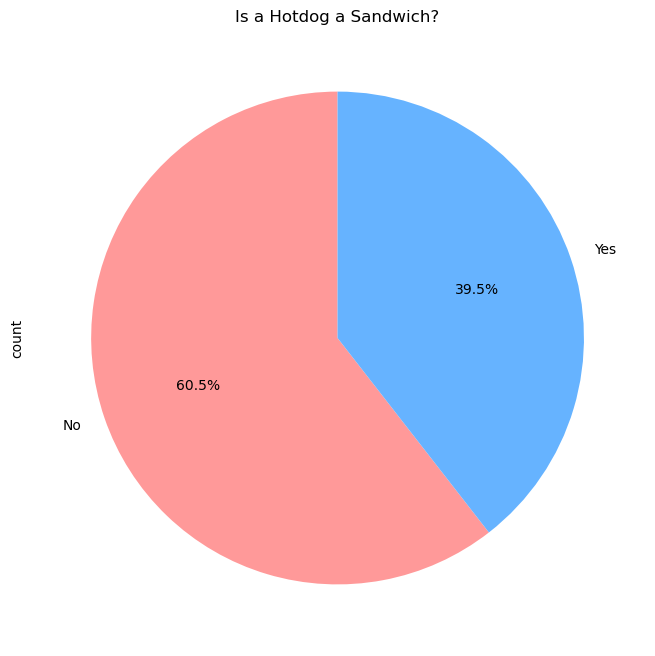

In [6]:
# create a pie chart of hotdog_opinion
plt.figure(figsize=(8,8))
hotdog['hotdog_opinion'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Is a Hotdog a Sandwich?')

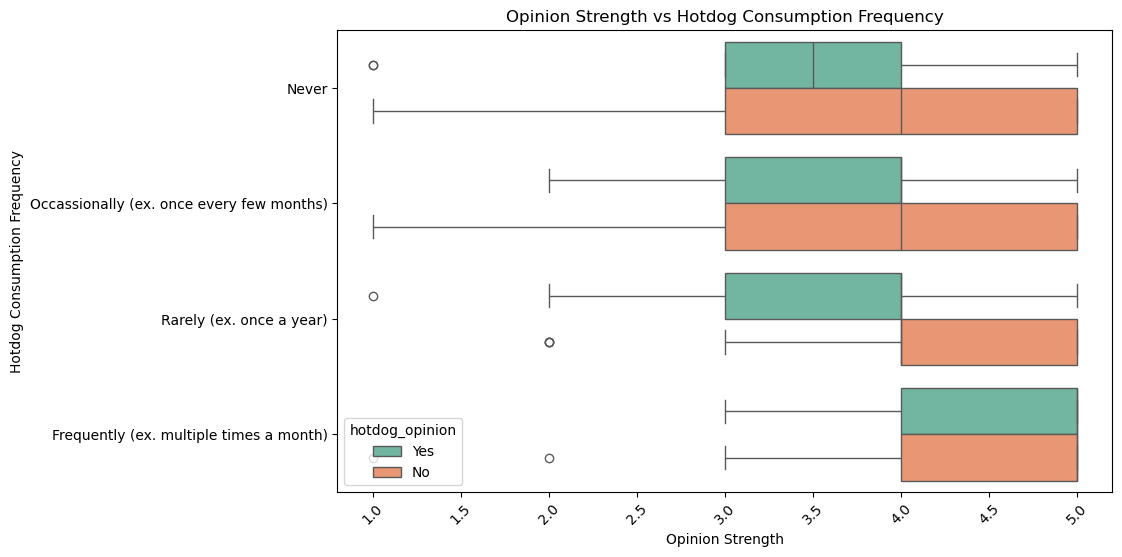

In [9]:
# create a plot showing opinion_strength vs consumption_freq
plt.figure(figsize=(10,6))
sns.boxplot(x='opinion_strength', y='consumption_freq', data=hotdog, palette='Set2',hue='hotdog_opinion')
plt.title('Opinion Strength vs Hotdog Consumption Frequency')
plt.xlabel('Opinion Strength')
plt.ylabel('Hotdog Consumption Frequency')
plt.xticks(rotation=45)
plt.show()

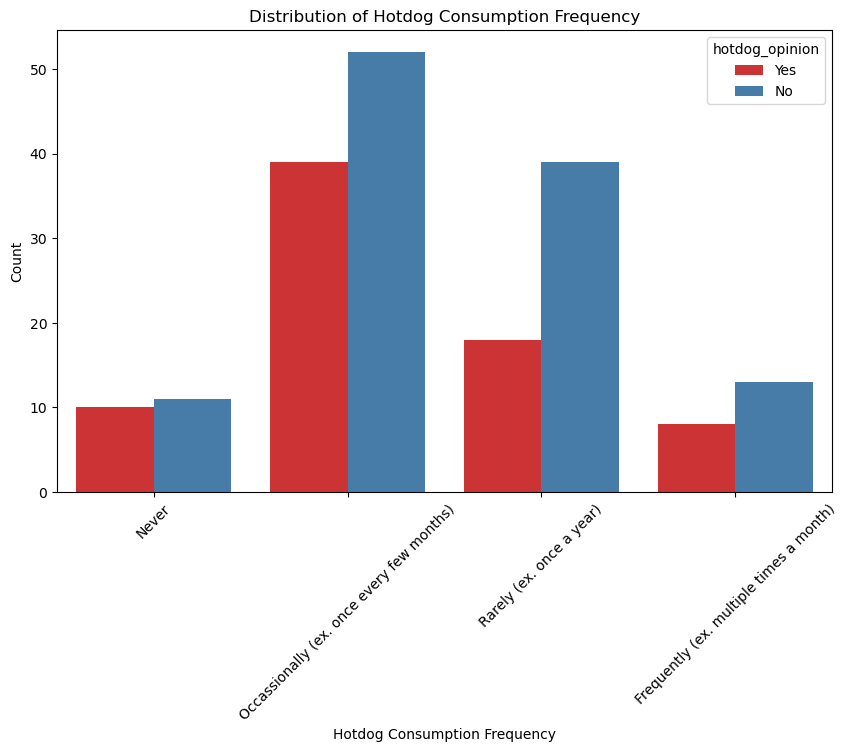

In [13]:
# Explore the distribution of hot dog consumption frequency
plt.figure(figsize=(10,6))
sns.countplot(x='consumption_freq', data=hotdog, palette='Set1',hue='hotdog_opinion')
plt.title('Distribution of Hotdog Consumption Frequency')
plt.xlabel('Hotdog Consumption Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

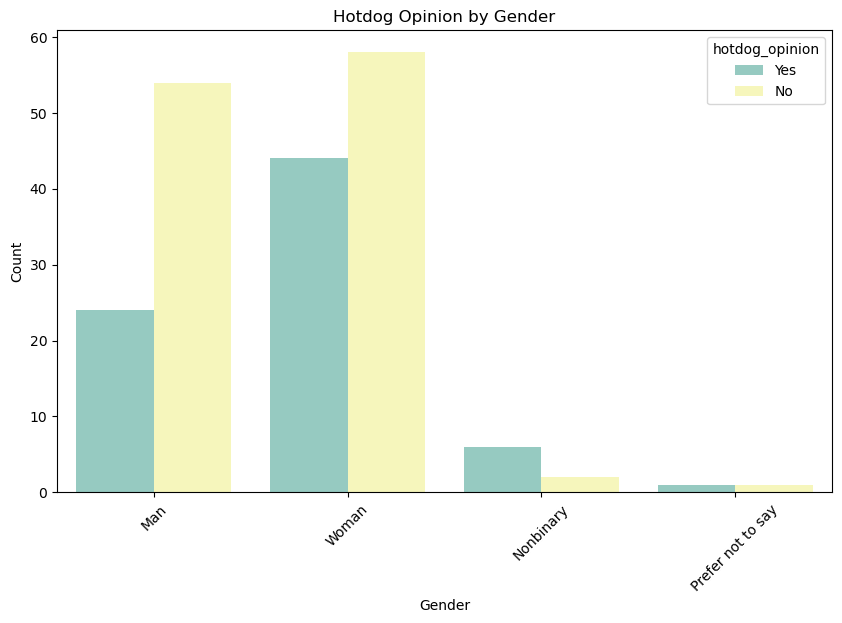

In [17]:
# hotdog_opinion vs gender
plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=hotdog, palette='Set3',hue='hotdog_opinion')
plt.title('Hotdog Opinion by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()